In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../utils"))  # repo utils/ (vendored sweep + shared helpers)
import os
import numpy as np
import numpy.matlib
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline

import sys
#sys.path.append("../utils")
from utils import *

In [2]:
rc_params = {
    'xtick.direction': 'in',
    'xtick.top': True,
    'ytick.direction': 'in',
    'ytick.right': True,
    'axes.edgecolor': 'k',
    'axes.labelcolor': 'k',
    'xtick.color': 'k',
    'ytick.color': 'k',
    'figure.facecolor': 'white',
    'font.size': 16,
    'axes.labelsize': 16,
    'legend.title_fontsize': 16,
    'axes.linewidth': 1.5,
    'xtick.major.size': 5,
    'xtick.major.width': 1.5,
    'xtick.minor.size': 2.5,
    'xtick.minor.width': 1.5,
    'ytick.major.size': 5,
    'ytick.major.width': 1.5,
    'ytick.minor.size': 2.5,
    'ytick.minor.width': 1.5,
    'lines.linewidth': 2.5,
    'figure.figsize': [3*1.618, 3]
}
plt.rcParams.update(rc_params)

In [3]:
h = 6.626E-34
e = 1.6002E-19
phi0 = h/e
dbg = 40.5
dtg = 26
ep = 3
Rq = h/e**2

In [4]:
import h5py


def load_LL_simulation_data(filepath, group="LL_simulation_data"):
    with h5py.File(filepath, "r") as f:
        return deserialize_LL_simulation_data(f[group])


def deserialize_LL_simulation_data(g):
    assert g.attrs["type"] == b'LL_simulation_data'

    sg = g["rhparams"]
    rhparams = {
        "n":      int(sg["n"][()]),
        "t0":     float(sg["t0"][()]),
        "t1":     float(sg["t1"][()]),
        "t2":     float(sg["t2"][()]),
        "t3":     float(sg["t3"][()]),
        "t4":     float(sg["t4"][()]),
        "delta":  float(sg["delta"][()]),
        "Deltas": sg["Deltas"][()],
    }

    # fluxes_pq: Julia writes (2, Nflux), h5py reads (Nflux, 2) due to C/Fortran order swap
    fluxes_pq = g["fluxes_pq"][()]
    fluxes = [(int(row[0]), int(row[1])) for row in fluxes_pq]

    ns_lin = np.linspace(
        float(g["ns_lin_start"][()]),
        float(g["ns_lin_stop"][()]),
        int(g["ns_lin_length"][()]),
    )

    return {
        "rhparams":             rhparams,
        "uD_meV":               float(g["uD_meV"][()]),
        "valley":               int(g["valley"][()]),
        "Nll":                  int(g["Nll"][()]),
        "T0_meV":               float(g["T0_meV"][()]),
        "Nenergies":            int(g["Nenergies"][()]),
        "fluxes":               fluxes,   # list of (p, q) int tuples
        "Es_all":               g["Es_all"][()],
        "ns_lines":             g["ns_lines"][()],
        "rhos_single_particle": g["rhos_single_particle"][()],
        "ns_lin":               ns_lin,
    }

# uD = 45, valley = 1

In [17]:
data_directory = "./"
fname = "../data/fig3/data_LL_uD_45.0_Nll_50_val_1_Bmin_0.01T_Bmax_3.79T.h5"
#fname = "../data/fig3/R4G_Landau_DOS_maps_tau_minus1_data.h5"
data = load_LL_simulation_data(fname)

ns_lin = data["ns_lin"]
fluxes = data["fluxes"]
Bs_arr = np.array([78912.31601883237*phi[0]/phi[1] for phi in fluxes])
rhos_mat = data["rhos_single_particle"]

In [18]:
xs = ns_lin
ys = Bs_arr
zs = rhos_mat

blo = 1
bhi = 4

indlo = np.abs(ys-blo).argmin()
indhi = np.abs(ys-bhi).argmin()
ys = ys[indlo:indhi]
zs = zs[indlo:indhi]    

padding = 4
psds, freqs = make_mat_fft_bw(ys, zs, xs, nx=len(ys), cutoff=None, order=4, padding=padding, normalize=True)
xs_repeated = np.tile(xs, (freqs.shape[0], 1))

/var/folders/q5/6h4h5k9n2t3g39wnfndbzhjr0000gn/T/ipykernel_13933/994485668.py:21: RuntimeWarning: invalid value encountered in multiply
  freqs2 = freqs * xs_repeated
/var/folders/q5/6h4h5k9n2t3g39wnfndbzhjr0000gn/T/ipykernel_13933/994485668.py:22: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax.pcolormesh(xs_repeated[::under_sample,1:len(xs):under_sample], freqs2[::under_sample,1:len(xs):under_sample], \


(0.0, 1.5)

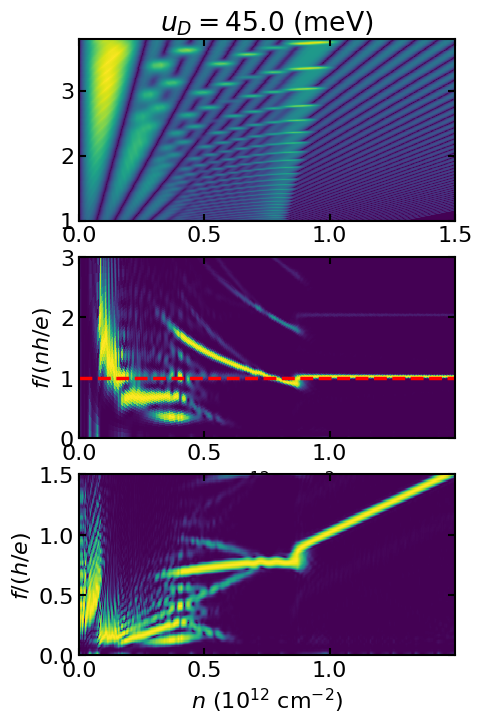

In [19]:
fig0, axs = plt.subplots(3,1, figsize=(3*1.618, 8))
ax = axs[0]
norm = colors.SymLogNorm(linthresh=10,)# vmin=100) #, vmax=1E4)
ax.pcolormesh(xs, ys, zs, norm=norm, cmap='viridis')
ax.set_title(r"$u_D = %.1f$ (meV)" % data["uD_meV"])

under_sample = 3 # speeds up plotting by skipping every under_sample # of points, 
#can set to 1 for plotting every point

ax = axs[1]
#the first row is bad for some reason. Skip it.
ax.pcolormesh(xs_repeated[::under_sample,1:len(xs):under_sample], freqs[::under_sample,1:len(xs):under_sample], \
              psds[::under_sample,1:len(xs):under_sample], norm=colors.SymLogNorm(linthresh=0.5, vmin=0, vmax=1), 
            cmap='viridis', rasterized=True, lw=0)
ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
ax.set_ylabel(r'$f/(nh/e)$')
ax.set_ylim(0, 3)
ax.axhline(1, color='r', linestyle='--')

ax = axs[2]
freqs2 = freqs * xs_repeated
ax.pcolormesh(xs_repeated[::under_sample,1:len(xs):under_sample], freqs2[::under_sample,1:len(xs):under_sample], \
              psds[::under_sample,1:len(xs):under_sample], norm=colors.SymLogNorm(linthresh=0.1, vmin=0, vmax=1), 
            cmap='viridis', rasterized=True, lw=0)
ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
ax.set_ylabel(r'$f/(h/e)$')
ax.set_ylim(0, 1.5)

# uD = 45, valley = -1

In [20]:
data_directory = "./"
fname = "../data/fig3/data_LL_uD_45.0_Nll_50_val_-1_Bmin_0.01T_Bmax_3.79T.h5"
#fname = "../data/fig3/R4G_Landau_DOS_maps_tau_minus1_data.h5"
data = load_LL_simulation_data(fname)

ns_lin = data["ns_lin"]
fluxes = data["fluxes"]
Bs_arr = np.array([78912.31601883237*phi[0]/phi[1] for phi in fluxes])
rhos_mat = data["rhos_single_particle"]

In [21]:
xs = ns_lin
ys = Bs_arr
zs = rhos_mat

blo = 1
bhi = 4

indlo = np.abs(ys-blo).argmin()
indhi = np.abs(ys-bhi).argmin()
ys = ys[indlo:indhi]
zs = zs[indlo:indhi]    

padding = 4
psds, freqs = make_mat_fft_bw(ys, zs, xs, nx=len(ys), cutoff=None, order=4, padding=padding, normalize=True)
xs_repeated = np.tile(xs, (freqs.shape[0], 1))

/var/folders/q5/6h4h5k9n2t3g39wnfndbzhjr0000gn/T/ipykernel_13933/994485668.py:21: RuntimeWarning: invalid value encountered in multiply
  freqs2 = freqs * xs_repeated
/var/folders/q5/6h4h5k9n2t3g39wnfndbzhjr0000gn/T/ipykernel_13933/994485668.py:22: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax.pcolormesh(xs_repeated[::under_sample,1:len(xs):under_sample], freqs2[::under_sample,1:len(xs):under_sample], \


(0.0, 1.5)

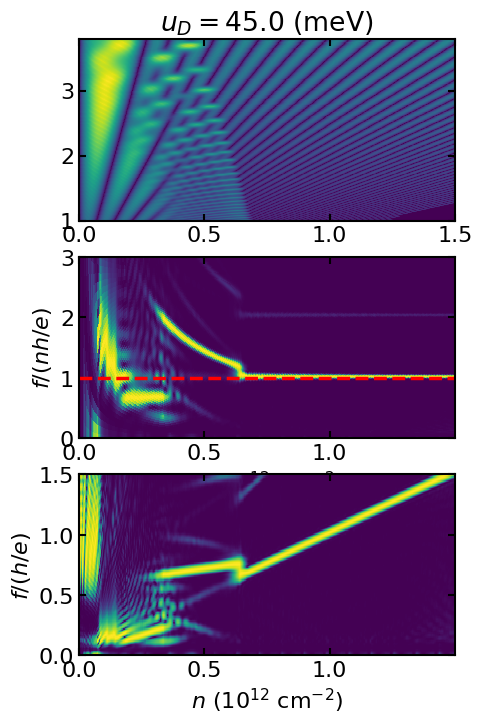

In [22]:
fig0, axs = plt.subplots(3,1, figsize=(3*1.618, 8))
ax = axs[0]
norm = colors.SymLogNorm(linthresh=10,)# vmin=100) #, vmax=1E4)
ax.pcolormesh(xs, ys, zs, norm=norm, cmap='viridis')
ax.set_title(r"$u_D = %.1f$ (meV)" % data["uD_meV"])

under_sample = 3 # speeds up plotting by skipping every under_sample # of points, 
#can set to 1 for plotting every point

ax = axs[1]
#the first row is bad for some reason. Skip it.
ax.pcolormesh(xs_repeated[::under_sample,1:len(xs):under_sample], freqs[::under_sample,1:len(xs):under_sample], \
              psds[::under_sample,1:len(xs):under_sample], norm=colors.SymLogNorm(linthresh=0.5, vmin=0, vmax=1), 
            cmap='viridis', rasterized=True, lw=0)
ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
ax.set_ylabel(r'$f/(nh/e)$')
ax.set_ylim(0, 3)
ax.axhline(1, color='r', linestyle='--')

ax = axs[2]
freqs2 = freqs * xs_repeated
ax.pcolormesh(xs_repeated[::under_sample,1:len(xs):under_sample], freqs2[::under_sample,1:len(xs):under_sample], \
              psds[::under_sample,1:len(xs):under_sample], norm=colors.SymLogNorm(linthresh=0.1, vmin=0, vmax=1), 
            cmap='viridis', rasterized=True, lw=0)
ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
ax.set_ylabel(r'$f/(h/e)$')
ax.set_ylim(0, 1.5)

# uD = 48, valley = 1

In [23]:
data_directory = "./"
fname = "../data/fig3/data_LL_uD_48.0_Nll_50_val_1_Bmin_0.01T_Bmax_3.79T.h5"
#fname = "../data/fig3/R4G_Landau_DOS_maps_tau_minus1_data.h5"
data = load_LL_simulation_data(fname)

ns_lin = data["ns_lin"]
fluxes = data["fluxes"]
Bs_arr = np.array([78912.31601883237*phi[0]/phi[1] for phi in fluxes])
rhos_mat = data["rhos_single_particle"]

In [24]:
xs = ns_lin
ys = Bs_arr
zs = rhos_mat

blo = 1
bhi = 4

indlo = np.abs(ys-blo).argmin()
indhi = np.abs(ys-bhi).argmin()
ys = ys[indlo:indhi]
zs = zs[indlo:indhi]    

padding = 4
psds, freqs = make_mat_fft_bw(ys, zs, xs, nx=len(ys), cutoff=None, order=4, padding=padding, normalize=True)
xs_repeated = np.tile(xs, (freqs.shape[0], 1))

/var/folders/q5/6h4h5k9n2t3g39wnfndbzhjr0000gn/T/ipykernel_13933/545695692.py:21: RuntimeWarning: invalid value encountered in multiply
  freqs2 = freqs * xs_repeated
/var/folders/q5/6h4h5k9n2t3g39wnfndbzhjr0000gn/T/ipykernel_13933/545695692.py:22: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax.pcolormesh(xs_repeated[::under_sample,1:len(xs):under_sample], freqs2[::under_sample,1:len(xs):under_sample], \


(0.0, 1.5)

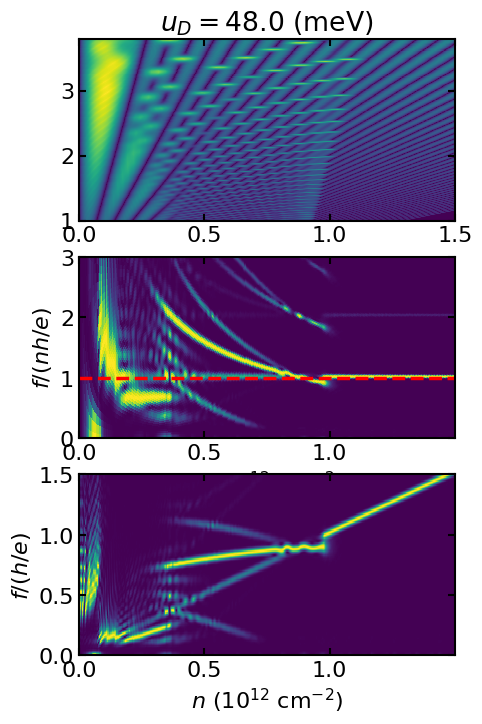

In [25]:
fig0, axs = plt.subplots(3,1, figsize=(3*1.618, 8))
ax = axs[0]
norm = colors.SymLogNorm(linthresh=10,)# vmin=100) #, vmax=1E4)
ax.pcolormesh(xs, ys, zs, norm=norm, cmap='viridis')
ax.set_title(r"$u_D = %.1f$ (meV)" % data["uD_meV"])

under_sample = 3 # speeds up plotting by skipping every under_sample # of points, 
#can set to 1 for plotting every point

ax = axs[1]
#the first row is bad for some reason. Skip it.
ax.pcolormesh(xs_repeated[::under_sample,1:len(xs):under_sample], freqs[::under_sample,1:len(xs):under_sample], \
              psds[::under_sample,1:len(xs):under_sample], norm=colors.SymLogNorm(linthresh=0.5, vmin=0, vmax=1), 
            cmap='viridis', rasterized=True, lw=0)
ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
ax.set_ylabel(r'$f/(nh/e)$')
ax.set_ylim(0, 3)
ax.axhline(1, color='r', linestyle='--')

ax = axs[2]
freqs2 = freqs * xs_repeated
ax.pcolormesh(xs_repeated[::under_sample,1:len(xs):under_sample], freqs2[::under_sample,1:len(xs):under_sample], \
              psds[::under_sample,1:len(xs):under_sample], norm=colors.SymLogNorm(linthresh=0.1, vmin=0, vmax=1), 
            cmap='viridis', rasterized=True, lw=0)
ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
ax.set_ylabel(r'$f/(h/e)$')
ax.set_ylim(0, 1.5)

# uD = 48, valley = -1

In [26]:
data_directory = "./"
fname = "../data/fig3/data_LL_uD_48.0_Nll_50_val_-1_Bmin_0.01T_Bmax_3.79T.h5"
#fname = "../data/fig3/R4G_Landau_DOS_maps_tau_minus1_data.h5"
data = load_LL_simulation_data(fname)

ns_lin = data["ns_lin"]
fluxes = data["fluxes"]
Bs_arr = np.array([78912.31601883237*phi[0]/phi[1] for phi in fluxes])
rhos_mat = data["rhos_single_particle"]

In [27]:
xs = ns_lin
ys = Bs_arr
zs = rhos_mat

blo = 1
bhi = 4

indlo = np.abs(ys-blo).argmin()
indhi = np.abs(ys-bhi).argmin()
ys = ys[indlo:indhi]
zs = zs[indlo:indhi]    

padding = 4
psds, freqs = make_mat_fft_bw(ys, zs, xs, nx=len(ys), cutoff=None, order=4, padding=padding, normalize=True)
xs_repeated = np.tile(xs, (freqs.shape[0], 1))

/var/folders/q5/6h4h5k9n2t3g39wnfndbzhjr0000gn/T/ipykernel_13933/4230637702.py:21: RuntimeWarning: invalid value encountered in multiply
  freqs2 = freqs * xs_repeated
/var/folders/q5/6h4h5k9n2t3g39wnfndbzhjr0000gn/T/ipykernel_13933/4230637702.py:22: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax.pcolormesh(xs_repeated[::under_sample,1:len(xs):under_sample], freqs2[::under_sample,1:len(xs):under_sample], \


(0.0, 1.5)

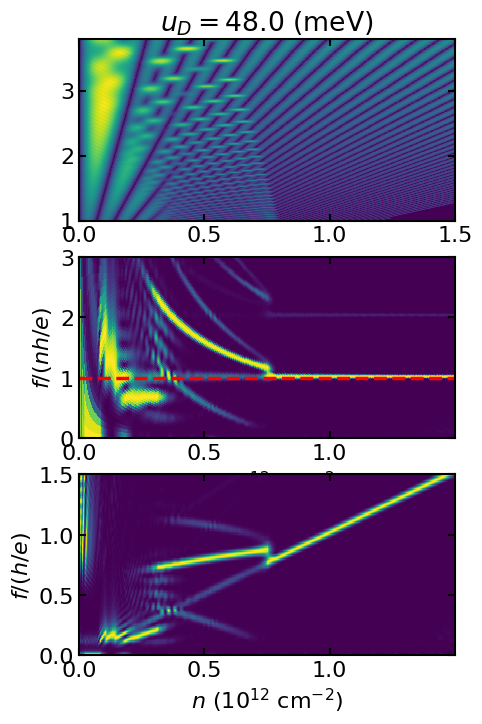

In [28]:
fig0, axs = plt.subplots(3,1, figsize=(3*1.618, 8))
ax = axs[0]
norm = colors.SymLogNorm(linthresh=10,)# vmin=100) #, vmax=1E4)
ax.pcolormesh(xs, ys, zs, norm=norm, cmap='viridis')
ax.set_title(r"$u_D = %.1f$ (meV)" % data["uD_meV"])

under_sample = 3 # speeds up plotting by skipping every under_sample # of points, 
#can set to 1 for plotting every point

ax = axs[1]
#the first row is bad for some reason. Skip it.
ax.pcolormesh(xs_repeated[::under_sample,1:len(xs):under_sample], freqs[::under_sample,1:len(xs):under_sample], \
              psds[::under_sample,1:len(xs):under_sample], norm=colors.SymLogNorm(linthresh=0.5, vmin=0, vmax=1), 
            cmap='viridis', rasterized=True, lw=0)
ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
ax.set_ylabel(r'$f/(nh/e)$')
ax.set_ylim(0, 3)
ax.axhline(1, color='r', linestyle='--')

ax = axs[2]
freqs2 = freqs * xs_repeated
ax.pcolormesh(xs_repeated[::under_sample,1:len(xs):under_sample], freqs2[::under_sample,1:len(xs):under_sample], \
              psds[::under_sample,1:len(xs):under_sample], norm=colors.SymLogNorm(linthresh=0.1, vmin=0, vmax=1), 
            cmap='viridis', rasterized=True, lw=0)
ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
ax.set_ylabel(r'$f/(h/e)$')
ax.set_ylim(0, 1.5)